In [1]:
# ========================================
# CELL 1 — Install Qwen2-VL Dependencies
# ========================================

!pip install -q transformers accelerate
!pip install -q pillow opencv-python
!pip install -q qwen-vl-utils
!pip install -q sentencepiece

print("✅ Qwen2-VL Dependencies Installed Successfully")

✅ Qwen2-VL Dependencies Installed Successfully


In [2]:
# ========================================
# CELL 2 — Upgrade Transformers
# ========================================

!pip install -U transformers accelerate

print("✅ Transformers Updated Successfully")

✅ Transformers Updated Successfully


In [9]:
# ========================================
# CELL 3 — Load Qwen2-VL-2B (Correct Model)
# ========================================

import torch
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

model_name = "Qwen/Qwen2-VL-2B-Instruct"

print("Loading processor...")
processor = AutoProcessor.from_pretrained(
    model_name,
    trust_remote_code=True
)

print("Loading model...")

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_name,
    device_map="cpu",
    torch_dtype=torch.float32
)

model.eval()

print("✅ Qwen2-VL-2B Loaded Successfully")

Loading processor...
Loading model...


Loading weights: 100%|██████████| 729/729 [00:00<00:00, 763.23it/s]


✅ Qwen2-VL-2B Loaded Successfully


In [6]:
# ========================================
# CELL 4 — Load Processor
# ========================================

from transformers import AutoProcessor

print("Loading processor...")

processor = AutoProcessor.from_pretrained(
    model_name,
    trust_remote_code=True
)

print("✅ Processor Loaded Successfully")

Loading processor...
✅ Processor Loaded Successfully


✅ Image Loaded Successfully


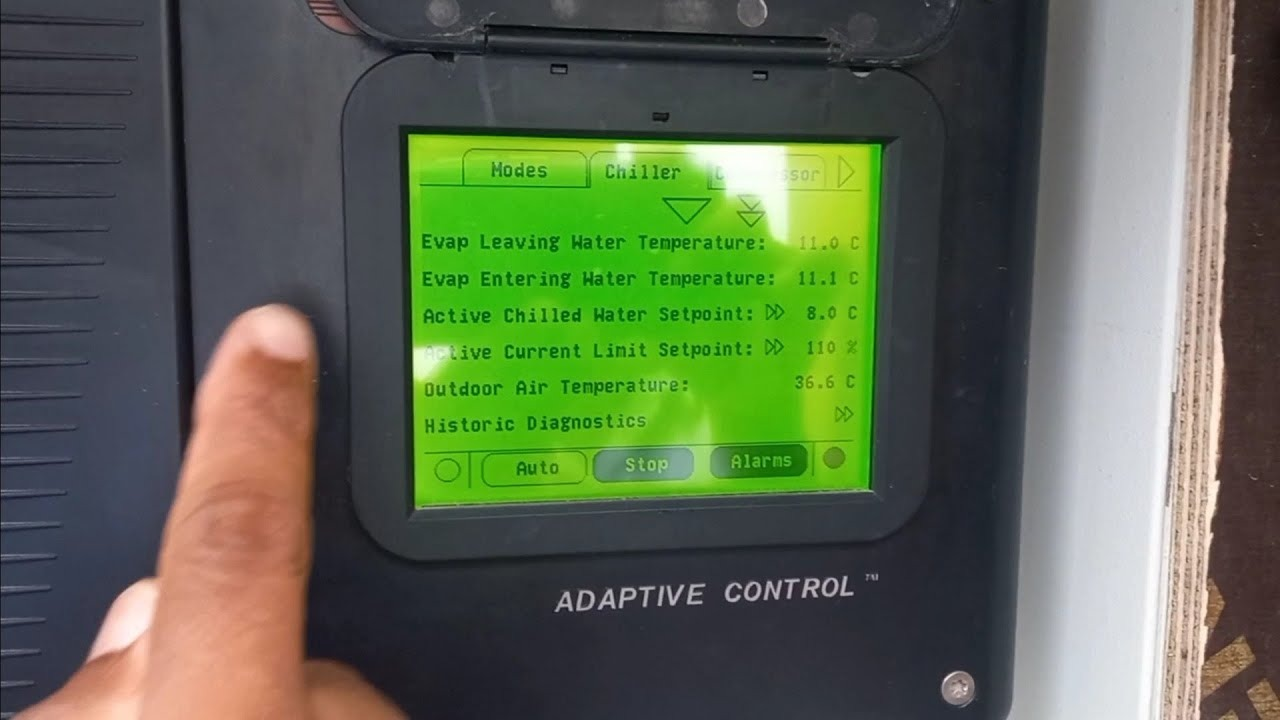

In [40]:
# ========================================
# CELL 5 — Load Energy Meter Image
# ========================================

from PIL import Image

# Put your image path here
image_path = "er.jpeg"

image = Image.open(image_path).convert("RGB")

print("✅ Image Loaded Successfully")

display(image)

In [42]:
# ========================================
# CELL 6 — Extract ALL Energy Meter Values
# ========================================

prompt = """
Analyze the energy meter display carefully.

Extract ALL variables and their corresponding values visible in the display.

Examples of variables:
- Voltage
- Current
- Power
- Energy
- kWh
- PF
- Frequency
- Any other parameter shown

Also extract:
- Date (if shown)
- Time (if shown)
- Day (if shown)

Return output in structured format:

Detected Values:
<Variable Name> : <Value>
<Variable Name> : <Value>

Date: <date or Not Available>
Time: <time or Not Available>
Day: <day or Not Available>

Rules:
- Extract ALL numbers with their variables
- Do not guess
- Only extract visible values
"""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ],
    }
]

# Apply chat template
text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=False
)

# Prepare inputs
inputs = processor(
    text=[text],
    images=[image],
    return_tensors="pt"
)

# ========================================
# Dynamic Token Limit
# ========================================

width, height = image.size

if width < 500:
    token_limit = 80
elif width < 1000:
    token_limit = 120
else:
    token_limit = 180

# Generate Output
outputs = model.generate(
    **inputs,
    max_new_tokens=token_limit
)

# Decode Response
response = processor.batch_decode(
    outputs,
    skip_special_tokens=True
)[0]

# ========================================
# Clean Only Assistant Output
# ========================================

if "assistant" in response:
    response = response.split("assistant")[-1].strip()

# ========================================
# Final Output
# ========================================

print("Extracted Energy Meter Values:\n")
print(response)

Extracted Energy Meter Values:

Detected Values:
Evap Leaving Water Temperature : 11.0°C
Evap Entering Water Temperature : 11.1°C
Active Chilled Water Setpoint : 8.0°C
Active Current Limit Setpoint : 110%
Outdoor Air Temperature : 36.6°C
Historic Diagnostics : Not Available

Date: Not Available
Time: Not Available
Day: Not Available


In [41]:
# ========================================
# CELL 6 — Extract ALL Display Variables
# ========================================

prompt = """
Carefully analyze the display screen.

Extract ALL variables and their corresponding numeric values visible on the display.

Instructions:
- Detect text labels on screen
- Detect numbers beside them
- Extract ALL label-value pairs
- Extract Date if present
- Extract Time if present
- Extract Day if present

Return ONLY in this format:

Detected Values:
<Variable> : <Value>
<Variable> : <Value>

Date: <value or Not Available>
Time: <value or Not Available>
Day: <value or Not Available>

Rules:
- Do not guess
- Do not skip any value
- Extract everything visible
- Do not explain
"""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ],
    }
]

# Apply chat template
text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=False
)

# Prepare inputs
inputs = processor(
    text=[text],
    images=[image],
    return_tensors="pt"
)

# ========================================
# Dynamic Token Logic
# ========================================

width, height = image.size

if width < 500:
    token_limit = 120
elif width < 1000:
    token_limit = 180
else:
    token_limit = 260


# Generate
outputs = model.generate(
    **inputs,
    max_new_tokens=token_limit,
    do_sample=False,
    temperature=0.0
)

# Decode
response = processor.batch_decode(
    outputs,
    skip_special_tokens=True
)[0]


# ========================================
# Clean Output
# ========================================

if "assistant" in response:
    response = response.split("assistant")[-1].strip()


# ========================================
# Final Output
# ========================================

print("Extracted Energy Meter Values:\n")
print(response)

Extracted Energy Meter Values:

Detected Values:
Evap Leaving Water Temperature : 11.0 C
Evap Entering Water Temperature : 11.1 C
Active Chilled Water Setpoint : 8.0 C
Active Current Limit Setpoint : 110 %
Outdoor Air Temperature : 36.6 C
Historic Diagnostics : Not Available

Date: Not Available
Time: Not Available
Day: Not Available

Rules:
- Do not guess
- Do not skip any value
- Extract everything visible
- Do not explain


In [43]:
# ========================================
# CELL 6 — Extract → JSON → Excel
# ========================================

import json
import pandas as pd
import re

prompt = """
Carefully analyze the display screen.

Extract ALL variables and their corresponding numeric values visible on the display.

Instructions:
- Detect text labels on screen
- Detect numbers beside them
- Extract ALL label-value pairs
- Extract Date if present
- Extract Time if present
- Extract Day if present

Return ONLY in this format:

Detected Values:
<Variable> : <Value>
<Variable> : <Value>

Date: <value or Not Available>
Time: <value or Not Available>
Day: <value or Not Available>

Rules:
- Do not guess
- Do not skip any value
- Extract everything visible
- Do not explain
"""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ],
    }
]

# Apply template
text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=False
)

inputs = processor(
    text=[text],
    images=[image],
    return_tensors="pt"
)

# ========================================
# Dynamic Token
# ========================================

width, height = image.size

if width < 500:
    token_limit = 120
elif width < 1000:
    token_limit = 180
else:
    token_limit = 260

# Generate
outputs = model.generate(
    **inputs,
    max_new_tokens=token_limit,
    do_sample=False,
    temperature=0.0
)

# Decode
response = processor.batch_decode(
    outputs,
    skip_special_tokens=True
)[0]

# Clean output
if "assistant" in response:
    response = response.split("assistant")[-1].strip()

print("Extracted Text:\n")
print(response)


# ========================================
# Convert Text → JSON
# ========================================

data = {}

lines = response.split("\n")

for line in lines:
    
    if ":" in line:
        key, value = line.split(":", 1)
        key = key.strip()
        value = value.strip()
        
        if key != "Detected Values":
            data[key] = value

print("\nJSON Format:\n")
print(json.dumps(data, indent=4))


# ========================================
# JSON → Excel
# ========================================

df = pd.DataFrame([data])

excel_file = "energy_meter_output.xlsx"
df.to_excel(excel_file, index=False)

print("\nExcel File Created:", excel_file)

Extracted Text:

Detected Values:
Evap Leaving Water Temperature : 11.0 C
Evap Entering Water Temperature : 11.1 C
Active Chilled Water Setpoint : 8.0 C
Active Current Limit Setpoint : 110 %
Outdoor Air Temperature : 36.6 C
Historic Diagnostics : Not Available

Date: Not Available
Time: Not Available
Day: Not Available

Rules:
- Do not guess
- Do not skip any value
- Extract everything visible
- Do not explain

JSON Format:

{
    "Evap Leaving Water Temperature": "11.0 C",
    "Evap Entering Water Temperature": "11.1 C",
    "Active Chilled Water Setpoint": "8.0 C",
    "Active Current Limit Setpoint": "110 %",
    "Outdoor Air Temperature": "36.6 C",
    "Historic Diagnostics": "Not Available",
    "Date": "Not Available",
    "Time": "Not Available",
    "Day": "Not Available",
    "Rules": ""
}

Excel File Created: energy_meter_output.xlsx
